# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 3 — Validación, Selección del Mejor Modelo y Evaluación Final en Test
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

Este notebook toma los 3 modelos entrenados en el Notebook 2 (Naive Bayes, Regresión Logística, Regresión Logística + Feature Engineering) y:

1. Los compara a todos en el conjunto de **validación**.
2. Elige el **mejor modelo** según ese criterio de validación.
3. Hace la **evaluación final — una única vez — sobre el conjunto de test**, que hasta ahora no fue tocado.
4. Compara el modelo elegido contra **TextBlob** (pre-entrenado) sobre ese mismo test, para responder la pregunta original de la consigna: ¿es mejor un modelo entrenado o uno pre-entrenado?

### Por qué separar esto del Notebook 2
Si eligiéramos el mejor modelo mirando el test, estaríamos "espiando" el conjunto que se supone íntegramente reservado para medir qué tan bien generaliza el modelo elegido — el test dejaría de ser una medición honesta. Por eso la selección se hace en validación, y el test se usa **una sola vez**, al final, solo para el modelo ya elegido.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)

train = pd.read_csv('../data/processed/split_train.csv')
val = pd.read_csv('../data/processed/split_val.csv')
test = pd.read_csv('../data/processed/split_test.csv')

with open('../data/processed/tfidf_vectorizer_mega.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('../data/processed/scaler_features.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../data/processed/nb_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)
with open('../data/processed/lr_model_mega.pkl', 'rb') as f:
    lr_model = pickle.load(f)
with open('../data/processed/lr_fe_model.pkl', 'rb') as f:
    lr_fe_model = pickle.load(f)

FEATURE_COLS = [
    'n_chars', 'n_words', 'avg_word_len', 'n_exclamation', 'n_question',
    'n_uppercase_words', 'n_elongated', 'n_pos_emoticons', 'n_neg_emoticons',
    'n_mentions_count', 'n_hashtags_count', 'n_lex_pos', 'n_lex_neg', 'lex_pos_neg_diff',
]

print('Train:', train.shape, '| Val:', val.shape, '| Test:', test.shape)


Train: (1114908, 30) | Val: (238910, 30) | Test: (238910, 30)


## 1. Vectorización de validación y test (con el vectorizador/scaler ya ajustados en train)

In [2]:
Xval = tfidf.transform(val['clean_text'])
Xtest = tfidf.transform(test['clean_text'])

Xval_feat = scaler.transform(val[FEATURE_COLS])
Xtest_feat = scaler.transform(test[FEATURE_COLS])

Xval_comb = hstack([Xval, csr_matrix(Xval_feat)])
Xtest_comb = hstack([Xtest, csr_matrix(Xtest_feat)])

yval = val['target']
ytest = test['target']


## 2. Comparación de los 3 candidatos en VALIDACIÓN

                      Modelo  F1 macro (validación)  F1 Neutral (validación)
    Regresión Logística + FE               0.580542                 0.129032
Regresión Logística (TF-IDF)               0.574019                 0.115385
                 Naive Bayes               0.527603                 0.013061


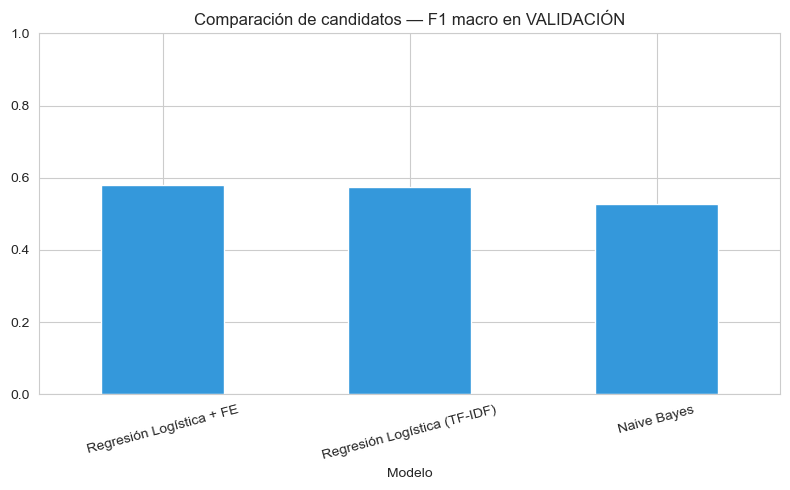

In [3]:
pred_val_nb = nb_model.predict(Xval)
pred_val_lr = lr_model.predict(Xval)
pred_val_lrfe = lr_fe_model.predict(Xval_comb)

comparacion_val = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Regresión Logística (TF-IDF)', 'Regresión Logística + FE'],
    'F1 macro (validación)': [
        f1_score(yval, pred_val_nb, average='macro'),
        f1_score(yval, pred_val_lr, average='macro'),
        f1_score(yval, pred_val_lrfe, average='macro'),
    ],
    'F1 Neutral (validación)': [
        f1_score(yval, pred_val_nb, labels=[2], average='macro', zero_division=0),
        f1_score(yval, pred_val_lr, labels=[2], average='macro', zero_division=0),
        f1_score(yval, pred_val_lrfe, labels=[2], average='macro', zero_division=0),
    ],
})
comparacion_val = comparacion_val.sort_values('F1 macro (validación)', ascending=False).reset_index(drop=True)
print(comparacion_val.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
comparacion_val.set_index('Modelo')['F1 macro (validación)'].plot(kind='bar', ax=ax, color='#3498db')
plt.title('Comparación de candidatos — F1 macro en VALIDACIÓN')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs_nb3_comparacion_validacion.png', dpi=110, bbox_inches='tight')
plt.show()


## 3. Selección del mejor modelo

**Criterio:** F1 macro en validación (no en test, para no sesgar la elección). Se usa F1 macro en vez de accuracy porque, con la clase neutral tan minoritaria, el accuracy podría ocultar un mal desempeño en esa clase.

In [4]:
nombre_ganador = comparacion_val.iloc[0]['Modelo']
print(f'Modelo elegido (mejor F1 macro en validación): {nombre_ganador}')


Modelo elegido (mejor F1 macro en validación): Regresión Logística + FE


In [5]:
# Mapeo de nombre -> (modelo, matrices de train/val/test que corresponden)
if nombre_ganador == 'Naive Bayes':
    modelo_final = nb_model
    Xtr_final, Xval_final, Xtest_final = tfidf.transform(train['clean_text']), Xval, Xtest
elif nombre_ganador == 'Regresión Logística (TF-IDF)':
    modelo_final = lr_model
    Xtr_final, Xval_final, Xtest_final = tfidf.transform(train['clean_text']), Xval, Xtest
else:
    modelo_final = lr_fe_model
    Xtr_feat_final = scaler.transform(train[FEATURE_COLS])
    Xtr_final = hstack([tfidf.transform(train['clean_text']), csr_matrix(Xtr_feat_final)])
    Xval_final, Xtest_final = Xval_comb, Xtest_comb

print(f'Usando: {nombre_ganador}')


Usando: Regresión Logística + FE


## 4. Evaluación final — ÚNICA vez sobre TEST

Esta es la primera y única vez que el conjunto de test se usa en todo el proyecto. El resultado acá es la medición más honesta de qué tan bien va a generalizar el modelo elegido a datos nuevos.

In [6]:
pred_test_final = modelo_final.predict(Xtest_final)

print(f'=== {nombre_ganador} — EVALUACIÓN FINAL EN TEST ===')
print(classification_report(ytest, pred_test_final, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))


=== Regresión Logística + FE — EVALUACIÓN FINAL EN TEST ===
              precision    recall  f1-score   support

    Negativo       0.82      0.79      0.81    119504
     Neutral       0.09      0.33      0.14        21
    Positivo       0.80      0.82      0.81    119385

    accuracy                           0.81    238910
   macro avg       0.57      0.65      0.59    238910
weighted avg       0.81      0.81      0.81    238910



## 5. Comparación Train / Validación / Test para el modelo elegido

Tabla completa de generalización: si el F1 de test es similar al de validación (y no muchísimo más bajo que el de train), el modelo generaliza razonablemente bien.

Modelo: Regresión Logística + FE

  Conjunto  F1 macro  Accuracy
     Train  0.699000  0.834780
Validación  0.580542  0.806191
      Test  0.586514  0.807501


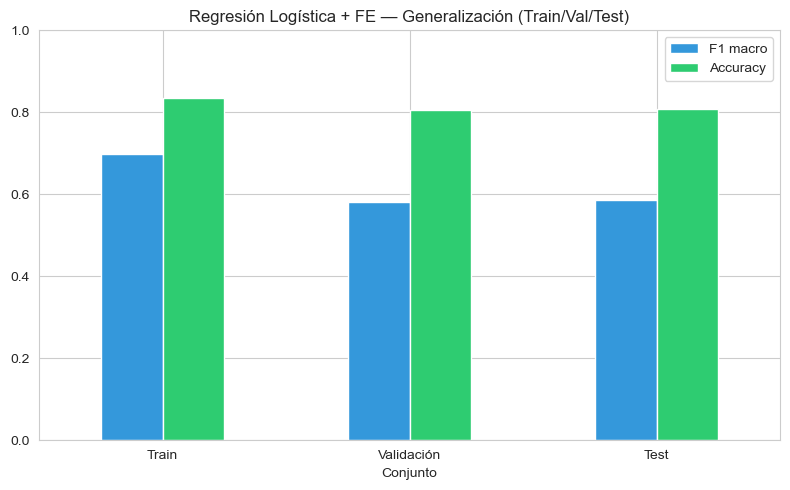

In [7]:
pred_train_final = modelo_final.predict(Xtr_final)
pred_val_final = modelo_final.predict(Xval_final)

tabla_final = pd.DataFrame({
    'Conjunto': ['Train', 'Validación', 'Test'],
    'F1 macro': [
        f1_score(train['target'], pred_train_final, average='macro'),
        f1_score(yval, pred_val_final, average='macro'),
        f1_score(ytest, pred_test_final, average='macro'),
    ],
    'Accuracy': [
        accuracy_score(train['target'], pred_train_final),
        accuracy_score(yval, pred_val_final),
        accuracy_score(ytest, pred_test_final),
    ],
})
print(f'Modelo: {nombre_ganador}\n')
print(tabla_final.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
tabla_final.set_index('Conjunto')[['F1 macro','Accuracy']].plot(kind='bar', ax=ax, color=['#3498db','#2ecc71'])
plt.title(f'{nombre_ganador} — Generalización (Train/Val/Test)')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs_nb3_generalizacion_final.png', dpi=110, bbox_inches='tight')
plt.show()


## 6. Comparación final: modelo elegido vs. TextBlob (pre-entrenado)

La pregunta original de la consigna: ¿un modelo entrenado (aunque sea sobre nuestros propios datos) es mejor que uno pre-entrenado de propósito general? Se responde acá, sobre el mismo test, para que la comparación sea justa.

In [8]:
from textblob import TextBlob

def textblob_predict_3clase(text, pos_th=0.1, neg_th=-0.1):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > pos_th:
        return 4
    elif polarity < neg_th:
        return 0
    else:
        return 2

tb_pred_test = test['text'].apply(textblob_predict_3clase)

print('=== TextBlob (pre-entrenado) — TEST ===')
print(classification_report(ytest, tb_pred_test, target_names=['Negativo','Neutral','Positivo'], labels=[0,2,4], zero_division=0))

comparacion_final = pd.DataFrame({
    'Modelo': [nombre_ganador, 'TextBlob (pre-entrenado)'],
    'F1 macro (test)': [
        f1_score(ytest, pred_test_final, average='macro'),
        f1_score(ytest, tb_pred_test, average='macro'),
    ],
    'Accuracy (test)': [
        accuracy_score(ytest, pred_test_final),
        accuracy_score(ytest, tb_pred_test),
    ],
})
print()
print(comparacion_final.to_string(index=False))


=== TextBlob (pre-entrenado) — TEST ===
              precision    recall  f1-score   support

    Negativo       0.79      0.27      0.40    119504
     Neutral       0.00      0.76      0.00        21
    Positivo       0.67      0.52      0.58    119385

    accuracy                           0.39    238910
   macro avg       0.48      0.52      0.33    238910
weighted avg       0.73      0.39      0.49    238910


                  Modelo  F1 macro (test)  Accuracy (test)
Regresión Logística + FE         0.586514         0.807501
TextBlob (pre-entrenado)         0.327870         0.393613


## 7. Matrices de confusión — modelo elegido vs. TextBlob (sobre test)

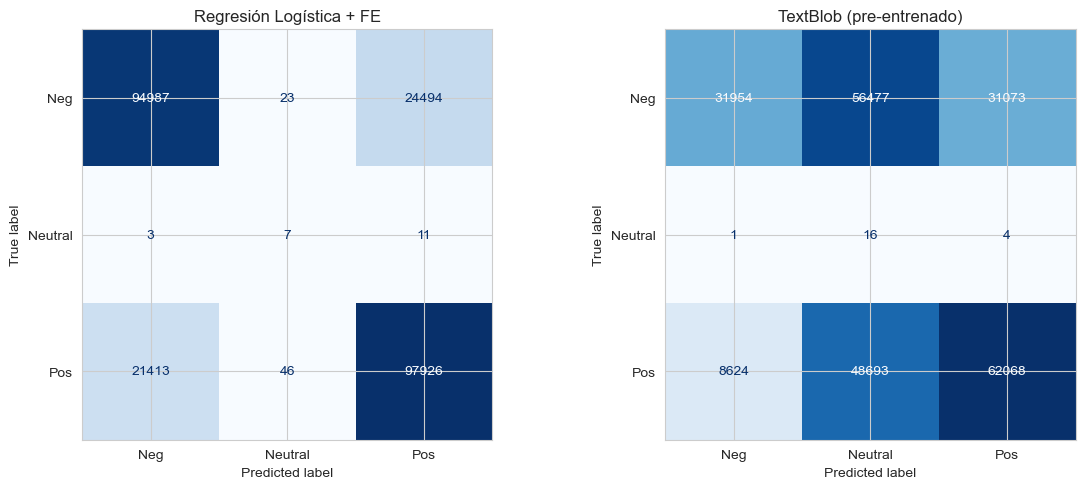

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm1 = confusion_matrix(ytest, pred_test_final, labels=[0,2,4])
ConfusionMatrixDisplay(cm1, display_labels=['Neg','Neutral','Pos']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(nombre_ganador)

cm2 = confusion_matrix(ytest, tb_pred_test, labels=[0,2,4])
ConfusionMatrixDisplay(cm2, display_labels=['Neg','Neutral','Pos']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('TextBlob (pre-entrenado)')

plt.tight_layout()
plt.savefig('outputs_nb3_matrices_confusion_final.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. Similitud coseno para interpretar errores del modelo elegido (en test)

In [10]:
test_df = test.copy()
test_df['pred'] = pred_test_final

errores = test_df[test_df['target'] != test_df['pred']]
print(f'Errores en test: {len(errores)} / {len(test_df)} ({len(errores)/len(test_df):.1%})')

if len(errores) > 0:
    idx_ejemplos = errores.index[:3]
    Xtr_text_full = tfidf.transform(train['clean_text'])
    sims = cosine_similarity(Xtest[idx_ejemplos], Xtr_text_full)

    for i, idx in enumerate(idx_ejemplos):
        row = test_df.loc[idx]
        top3 = sims[i].argsort()[::-1][:3]
        print(f"\nTweet mal clasificado (real={row['target']}, predicho={row['pred']}): '{row['text'][:100]}'")
        for t in top3:
            print(f"   sim={sims[i][t]:.2f} | target={train.loc[t,'target']} | {train.loc[t,'text'][:80]}")


Errores en test: 45990 / 238910 (19.2%)

Tweet mal clasificado (real=4, predicho=0): '@BirdyLay haa desperate for friends? i wanna verse you in mario kart! i play 24/7 when i go home... '
   sim=0.52 | target=4 | @terryleahy mario kart. 
   sim=0.51 | target=0 | What1how i miss mario kart 
   sim=0.49 | target=4 | Once again, I win at Mario Kart. 

Tweet mal clasificado (real=4, predicho=0): '@ebassman #FULLSERVICE Is what we want!!! '
   sim=0.58 | target=0 | #FULLSERVICE why wont my pic show. 
   sim=0.58 | target=4 | 15 days till I get #FullService 
   sim=0.58 | target=4 | @ChristinaluvzJK be surprised   NO VIDEOS... #FULLSERVICE

Tweet mal clasificado (real=4, predicho=0): 'Just talked to @samgrover's cute grandma on the phone.  She only speaks Hindi-not my best language-b'
   sim=0.43 | target=0 | What? I'm not the best? 
   sim=0.43 | target=0 | not the best 
   sim=0.41 | target=0 | Just talked to my grandma, she isn't doing too good 


## 9. Guardado del modelo final elegido

In [11]:
with open('../data/processed/modelo_final_elegido.pkl', 'wb') as f:
    pickle.dump({'nombre': nombre_ganador, 'modelo': modelo_final}, f)

comparacion_val.to_csv('../data/processed/comparacion_validacion.csv', index=False)
tabla_final.to_csv('../data/processed/tabla_generalizacion_final.csv', index=False)
comparacion_final.to_csv('../data/processed/comparacion_final_vs_textblob.csv', index=False)

print(f'Guardado: ../data/processed/modelo_final_elegido.pkl (modelo: {nombre_ganador})')


Guardado: ../data/processed/modelo_final_elegido.pkl (modelo: Regresión Logística + FE)


## 10. Resumen de decisiones — Notebook 3

1. Se compararon los 3 modelos candidatos (entrenados en el Notebook 2) **en validación** — un conjunto que ninguno vio durante el entrenamiento — usando F1 macro como criterio de selección.
2. Se eligió el modelo con mejor F1 macro en validación, evitando elegir mirando el test (lo que hubiera sesgado la evaluación final).
3. El conjunto de **test se usó una única vez**, exclusivamente para medir la generalización del modelo ya elegido — no se usó en ningún momento anterior del proyecto.
4. Se comparó el modelo elegido contra TextBlob (pre-entrenado) sobre ese mismo test, respondiendo la pregunta original de la consigna.
5. Se usó similitud coseno para interpretar los errores del modelo final sobre test.

**Continúa en `04_predicciones.ipynb`** (uso del modelo elegido para generar predicciones).